# FAKE NEWS DETECTION - CLEAN VERSION
# Models used:
# 1) Logistic Regression
# 2) Linear SVM
# 3) DistilBERT


# 1. INSTALL DEPENDENCIES

In [ ]:
# Run these in Colab if needed
!pip install -q nltk wordcloud textblob sentence-transformers scikit-learn pandas numpy matplotlib seaborn
!pip install -q transformers datasets accelerate evaluate openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


# 2. IMPORT LIBRARIES

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from textblob import TextBlob

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

import torch
import evaluate
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. CONFIGURATION

In [ ]:
FILE_PATH = "/content/drive/MyDrive/WELFake_Dataset.csv"   # change if needed
RANDOM_STATE = 42
TEST_SIZE = 0.2
DISTILBERT_SAMPLE_SIZE = 10000
DISTILBERT_CHECKPOINT = "distilbert-base-uncased"



# 4. LOAD AND CLEAN DATA

In [ ]:

def load_and_clean_data(file_path):
    df = pd.read_csv(file_path)

    print("Original Shape:", df.shape)

    # Drop unwanted column if present
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")

    # Remove missing title/text
    df = df.dropna(subset=["title", "text"])

    # Remove empty strings
    df = df[
        (df["title"].astype(str).str.strip() != "") &
        (df["text"].astype(str).str.strip() != "")
    ].copy()

    # Remove duplicates
    df = df.drop_duplicates().reset_index(drop=True)

    # Label mapping for display
    df["label_name"] = df["label"].map({0: "Fake", 1: "Real"})

    # Basic features
    df["title_length"] = df["title"].astype(str).apply(len)
    df["text_length"] = df["text"].astype(str).apply(len)
    df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
    df["sentiment"] = df["text"].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

    # Combine title + text
    df["combined_text"] = df["title"].astype(str) + " " + df["text"].astype(str)

    print("Cleaned Shape:", df.shape)
    print(df.head())

    return df




# 5. EXPLORATORY DATA ANALYSIS

In [ ]:

def run_eda(df):
    print("\nMissing Values:\n", df.isnull().sum())

    # Class distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="label_name")
    plt.title("Fake vs Real News Distribution")
    plt.xlabel("News Label")
    plt.ylabel("Count")
    plt.show()

    # Word count distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df["word_count"], bins=150)
    plt.xlim(0, 1500)
    plt.title("Word Count Distribution")
    plt.xlabel("Number of Words")
    plt.show()

    # Top words
    vectorizer = CountVectorizer(stop_words="english", max_features=20)
    X_counts = vectorizer.fit_transform(df["text"].astype(str))
    words = vectorizer.get_feature_names_out()
    counts = X_counts.toarray().sum(axis=0)

    freq_df = pd.DataFrame({"word": words, "count": counts}).sort_values(by="count", ascending=False)
    print("\nTop Frequent Words:\n", freq_df)

    # Wordcloud - all
    text_all = " ".join(df["text"].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_all)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("WordCloud of News Articles")
    plt.show()

    # Wordcloud - fake
    fake_text = " ".join(df[df["label"] == 0]["text"].astype(str))
    wc_fake = WordCloud(width=800, height=400, background_color="white").generate(fake_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc_fake)
    plt.axis("off")
    plt.title("Fake News WordCloud")
    plt.show()

    # Wordcloud - real
    real_text = " ".join(df[df["label"] == 1]["text"].astype(str))
    wc_real = WordCloud(width=800, height=400, background_color="white").generate(real_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc_real)
    plt.axis("off")
    plt.title("Real News WordCloud")
    plt.show()

    # Correlation heatmap
    numeric_cols = df[["title_length", "text_length", "word_count"]]
    plt.figure(figsize=(6, 4))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    # Sentiment distribution
    plt.figure(figsize=(6, 4))
    sns.histplot(df["sentiment"], bins=20)
    plt.title("Sentiment Distribution")
    plt.show()


# Running EDA

Original Shape: (72134, 4)
Cleaned Shape: (62592, 9)
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
2  Bobby Jindal, raised Hindu, uses story of Chri...   
3  SATAN 2: Russia unvelis an image of its terrif...   
4  About Time! Christian Group Sues Amazon and SP...   

                                                text  label label_name  \
0  No comment is expected from Barack Obama Membe...      1       Real   
1   Now, most of the demonstrators gathered last ...      1       Real   
2  A dozen politically active pastors came here f...      0       Fake   
3  The RS-28 Sarmat missile, dubbed Satan 2, will...      1       Real   
4  All we can say on this one is it s about time ...      1       Real   

   title_length  text_length  word_count  sentiment  \
0           130         5049         871   0.033103   
1           137          216          34   0.258929   


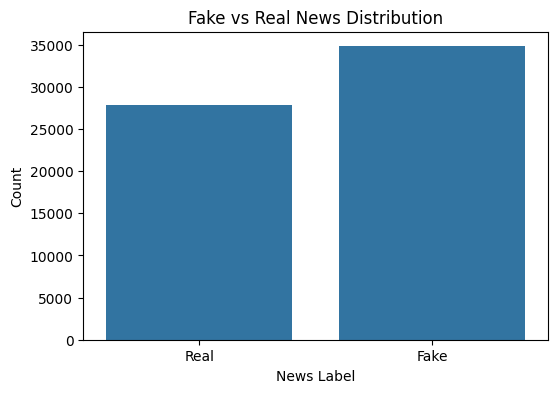

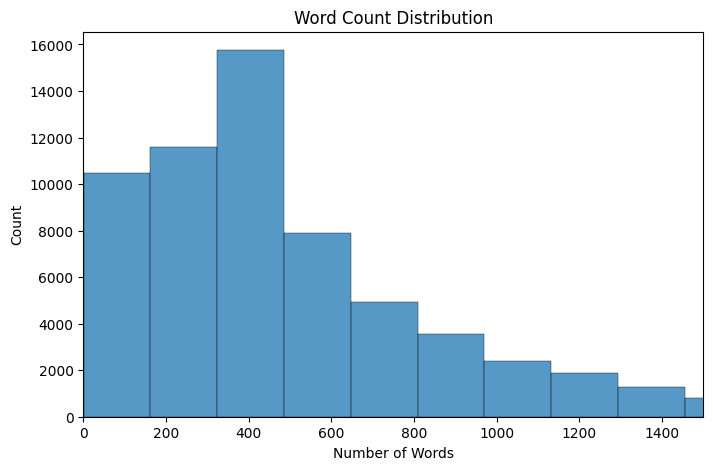


Top Frequent Words:
           word   count
13        said  220638
17       trump  196002
11   president   80639
10      people   79948
7           mr   70779
8          new   63736
1      clinton   62482
14       state   57390
6         like   49876
5         just   47773
15      states   45877
3   government   44607
9        obama   44093
16        time   43623
19        year   40984
4        house   40786
2       donald   38620
18      united   38503
0     campaign   38365
12  republican   37074


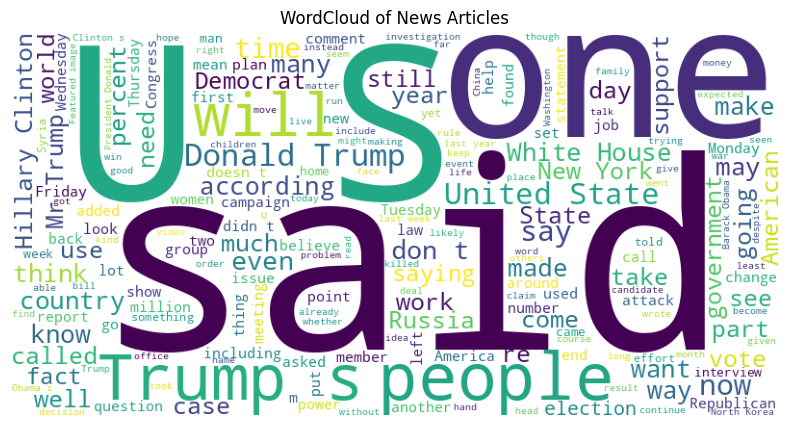

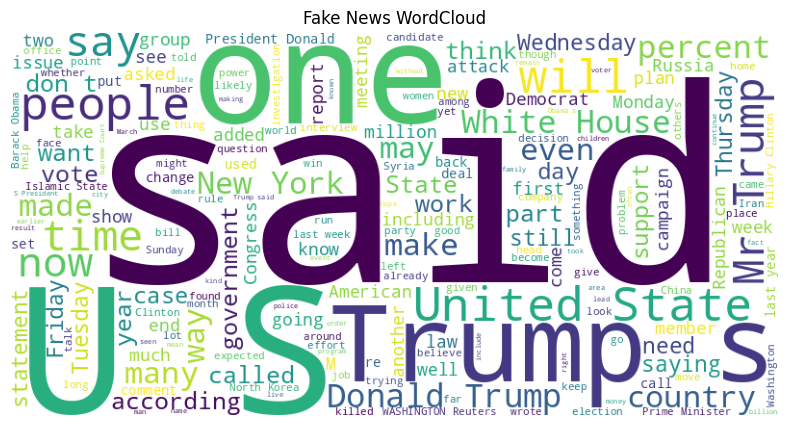

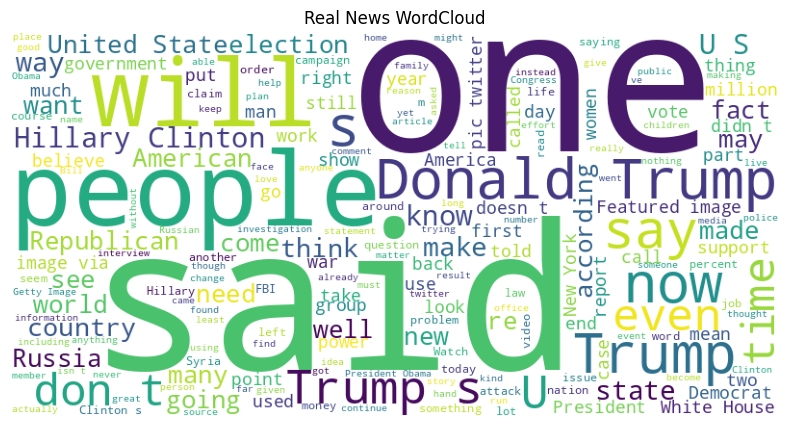

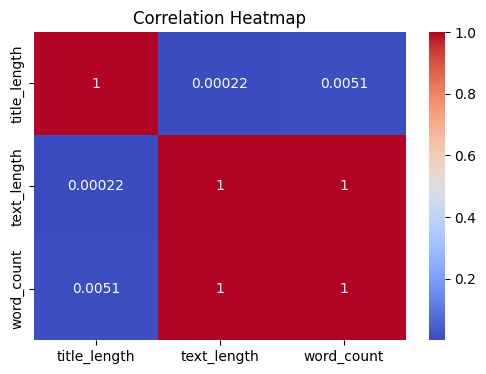

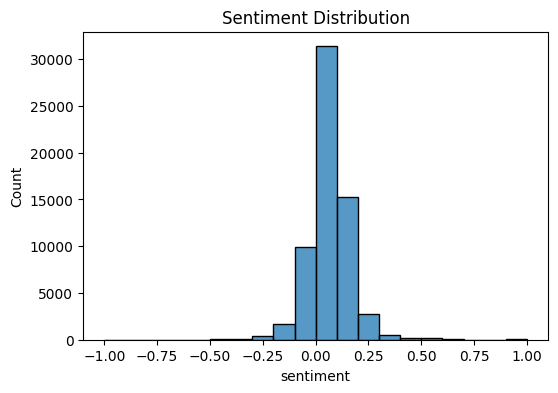

In [ ]:
 df = load_and_clean_data(FILE_PATH)
run_eda(df)

# 6. COMMON EVALUATION FUNCTION

In [ ]:
def evaluate_model(model_name, y_true, y_pred, y_score=None):
    print(f"\n{'=' * 50}")
    print(f"{model_name} RESULTS")
    print(f"{'=' * 50}")

    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # ROC Curve
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()

    return acc



# 7. TF-IDF PREPARATION

In [ ]:

def prepare_tfidf_data(df):
    X = df["combined_text"]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        ngram_range=(1, 2)
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    return X_train, X_test, y_train, y_test, vectorizer, X_train_tfidf, X_test_tfidf



# 8. LOGISTIC REGRESSION

In [ ]:
def train_logistic_regression(X_train_tfidf, X_test_tfidf, y_train, y_test):
    lr_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    lr_model.fit(X_train_tfidf, y_train)

    y_pred = lr_model.predict(X_test_tfidf)
    y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

    lr_accuracy = evaluate_model(
        model_name="Logistic Regression",
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_prob
    )

    return lr_model, lr_accuracy

# 9. LEARNING CURVE - LR

In [ ]:
def plot_learning_curve(model, X_train_tfidf, y_train):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train_tfidf,
        y=y_train,
        cv=3,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, label="Training Accuracy")
    plt.plot(train_sizes, val_mean, label="Validation Accuracy")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve - Logistic Regression")
    plt.legend()
    plt.show()

# 10. SAMPLE PREDICTION - LR

In [ ]:
def predict_sample_news(model, vectorizer, sample_text):
    sample_tfidf = vectorizer.transform([sample_text])
    prediction = model.predict(sample_tfidf)[0]

    label_map = {0: "Fake", 1: "Real"}
    print("Sample Text Prediction:", label_map[prediction])


# Result


Logistic Regression RESULTS
Accuracy: 0.9470404984423676

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      6958
           1       0.93      0.95      0.94      5561

    accuracy                           0.95     12519
   macro avg       0.95      0.95      0.95     12519
weighted avg       0.95      0.95      0.95     12519



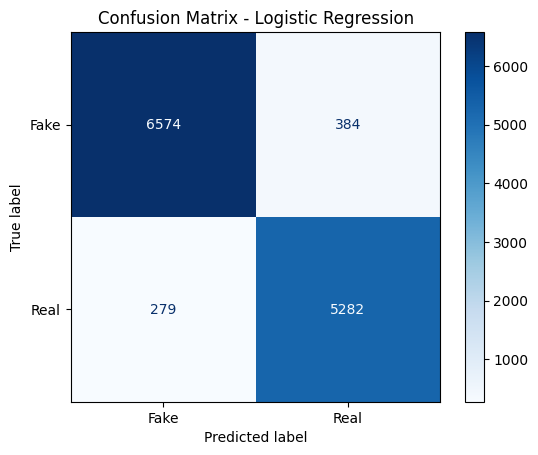

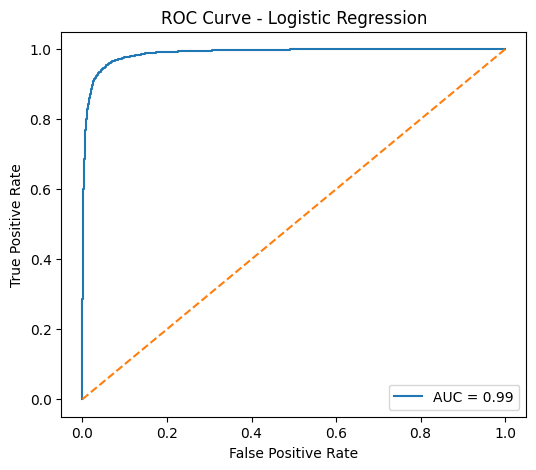

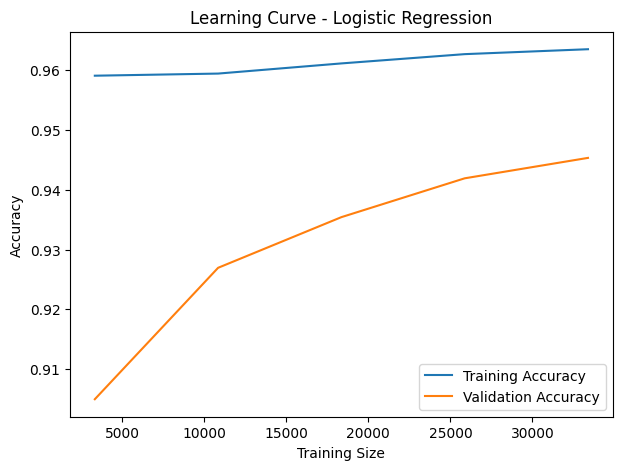

Sample Text Prediction: Real


In [ ]:
# 1. Prepare data
X_train, X_test, y_train, y_test, vectorizer, X_train_tfidf, X_test_tfidf = prepare_tfidf_data(df)

# 2. Train + evaluate
lr_model, lr_accuracy = train_logistic_regression(
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

# 3. Learning curve
plot_learning_curve(lr_model, X_train_tfidf, y_train)

# 4. Prediction
predict_sample_news(lr_model, vectorizer, "Sample news text here")

# 11. LINEAR SVM

In [ ]:
def train_svm(X_train_tfidf, X_test_tfidf, y_train, y_test):
    # 1. Initialize the model
    svm_model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=42 # Or your RANDOM_STATE variable
    )

    # 2. TRAIN the model (Use .fit, NOT the function name)
    svm_model.fit(X_train_tfidf, y_train)


    # 3. Predict and Calculate Accuracy
    y_pred = svm_model.predict(X_test_tfidf)
    y_scores = svm_model.decision_function(X_test_tfidf)
    svm_acc = accuracy_score(y_test, y_pred)

    # 4. Print results
    print("\nLinear SVM RESULTS")
    print("=" * 50)
    print(f"Accuracy: {svm_acc}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return svm_model, svm_acc, y_pred, y_scores

svm_model, svm_acc, y_pred, y_scores = train_svm(X_train_tfidf, X_test_tfidf, y_train, y_test)


Linear SVM RESULTS
Accuracy: 0.9591021647096414

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      6958
           1       0.95      0.96      0.95      5561

    accuracy                           0.96     12519
   macro avg       0.96      0.96      0.96     12519
weighted avg       0.96      0.96      0.96     12519



# Confusion Matrix

In [ ]:

def show_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Fake", "Real"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# ROC CURVE

In [ ]:
def show_roc_curve(model_name, y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

# Result


Linear SVM RESULTS
Accuracy: 0.9591021647096414

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      6958
           1       0.95      0.96      0.95      5561

    accuracy                           0.96     12519
   macro avg       0.96      0.96      0.96     12519
weighted avg       0.96      0.96      0.96     12519



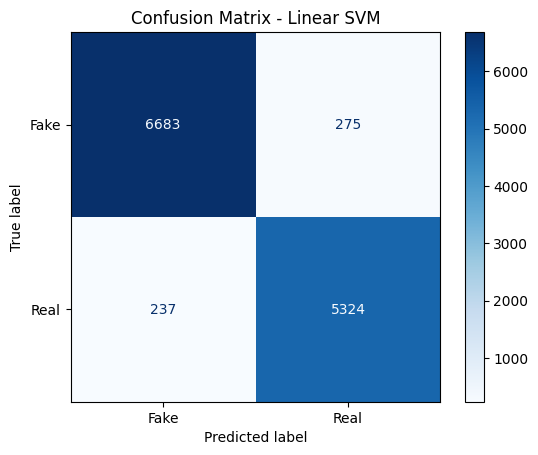

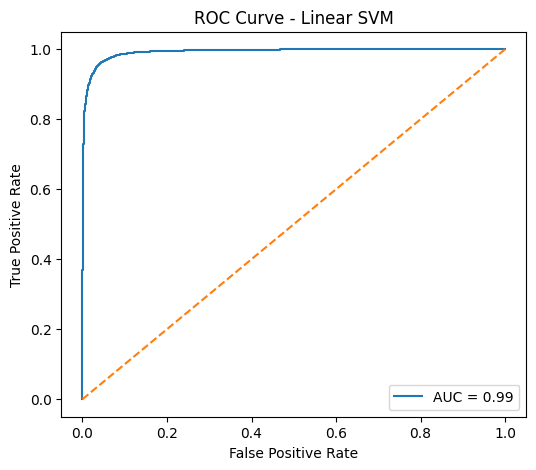

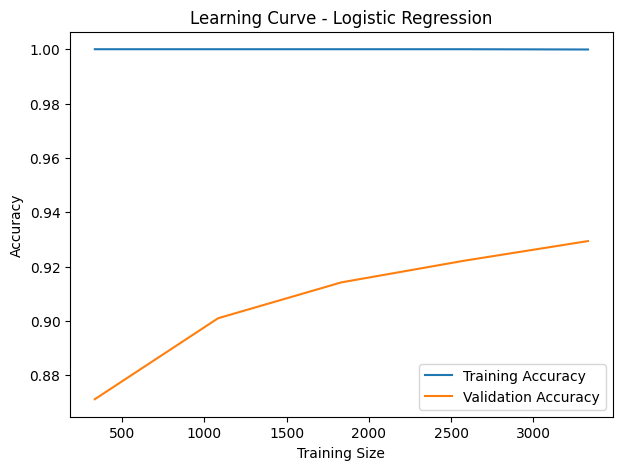

In [ ]:
# Train SVM
svm_model, svm_accuracy, y_pred_svm, y_scores_svm = train_svm(
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

# One confusion matrix
show_confusion_matrix("Linear SVM", y_test, y_pred_svm)

# One ROC curve
show_roc_curve("Linear SVM", y_test, y_scores_svm)

# One learning curve
plot_learning_curve(svm_model, X_train_tfidf[:5000], y_train[:5000])

# 12. DISTILBERT DATA PREP

In [ ]:
df = df.sample(n=500, random_state=42).copy()
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# =========================
# 5. CONVERT TO DATASET FORMAT
# =========================
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})

print(dataset)


ValueError: Cannot take a larger sample than population when 'replace=False'

# 13. DISTILBERT TRAINING

In [ ]:
# =========================
# 6. LOAD TOKENIZER
# =========================
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


# =========================
# 7. TOKENIZE DATA
# =========================
def tokenize_function(examples):
    return tokenizer(
        examples["combined_text"],
        truncation=True,
        max_length=64
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# =========================
# 8. LOAD METRICS
# =========================
accuracy_metric = evaluate.load("accuracy")
recall_metric = evaluate.load("recall")


# =========================
# 9. COMPUTE METRICS
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    recall = recall_metric.compute(
        predictions=predictions,
        references=labels
    )["recall"]

    return {
        "accuracy": accuracy,
        "recall": recall
    }


# =========================
# 10. LOAD MODEL
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 # 14. DISTILBERT TRAINING PLOTS

In [ ]:
# =========================
# 11. TRAINING ARGUMENTS
# =========================
training_args = TrainingArguments(
    output_dir="./distilbert_fake_news",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)


# =========================
# 12. CREATE TRAINER
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


# =========================
# 13. TRAIN MODEL
# =========================
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Recall
1,0.000486,0.449252,0.920000,0.863636
2,0.000096,0.278236,0.960000,0.954545
3,0.000053,0.303866,0.940000,0.909091
4,0.000041,0.306557,0.940000,0.909091
5,0.000035,0.291465,0.960000,0.954545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=250, training_loss=0.0001422756933607161, metrics={'train_runtime': 915.7269, 'train_samples_per_second': 2.184, 'train_steps_per_second': 0.273, 'total_flos': 33116849664000.0, 'train_loss': 0.0001422756933607161, 'epoch': 5.0})


DistilBERT Final Results
Accuracy: 0.96
Recall: 0.9090909090909091


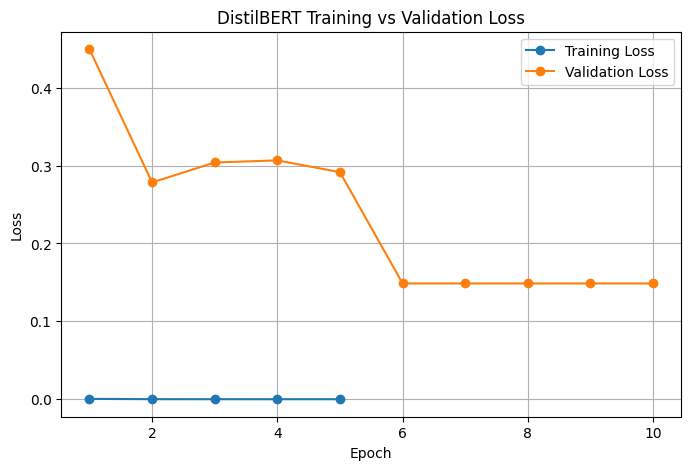

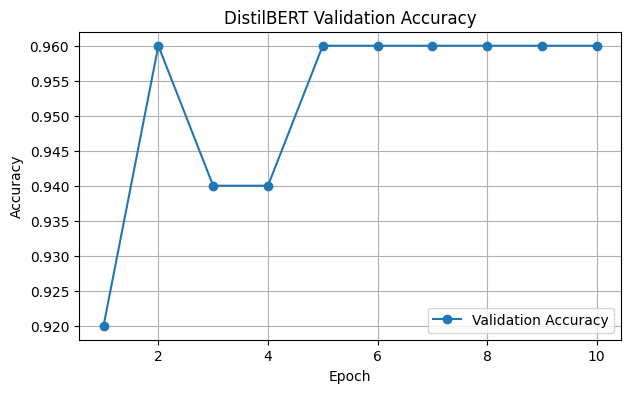

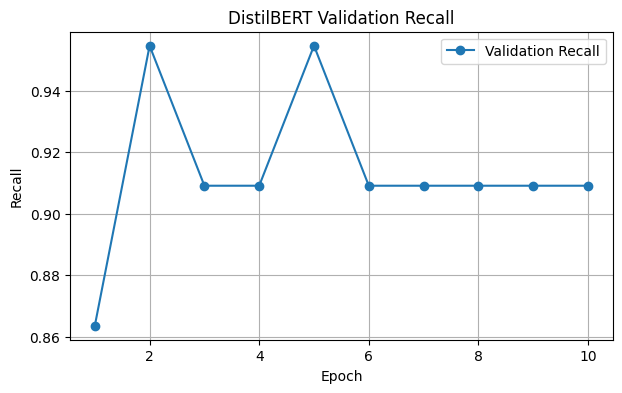


DistilBERT Confusion Matrix


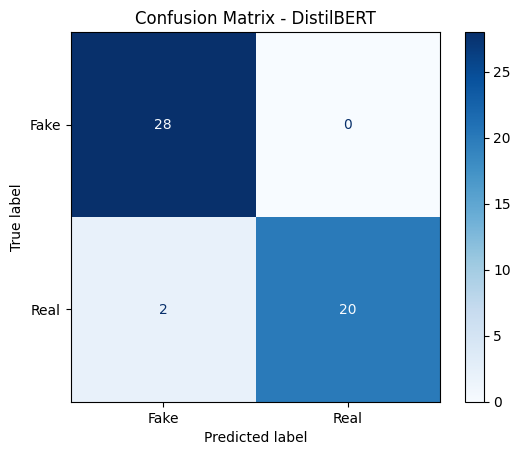

In [ ]:
# =========================
# 14. FINAL TEST RESULTS
# =========================
results = trainer.evaluate(tokenized_datasets["test"])
distilbert_accuracy = results["eval_accuracy"]
print("\nDistilBERT Final Results")
print("=" * 40)
print("Accuracy:", results["eval_accuracy"])
print("Recall:", results["eval_recall"])


# =========================
# 15. GRAPH FUNCTION
# =========================
def plot_distilbert_graphs(trainer):
    history = trainer.state.log_history

    train_loss = []
    eval_loss = []
    eval_accuracy = []
    eval_recall = []

    for log in history:
        if "loss" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])

        if "eval_loss" in log:
            eval_loss.append(log["eval_loss"])

        if "eval_accuracy" in log:
            eval_accuracy.append(log["eval_accuracy"])

        if "eval_recall" in log:
            eval_recall.append(log["eval_recall"])

    # Training vs Validation Loss
    plt.figure(figsize=(8, 5))
    if len(train_loss) > 0:
        plt.plot(range(1, len(train_loss) + 1), train_loss, marker="o", label="Training Loss")
    if len(eval_loss) > 0:
        plt.plot(range(1, len(eval_loss) + 1), eval_loss, marker="o", label="Validation Loss")
    plt.title("DistilBERT Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Validation Accuracy
    plt.figure(figsize=(7, 4))
    if len(eval_accuracy) > 0:
        plt.plot(range(1, len(eval_accuracy) + 1), eval_accuracy, marker="o", label="Validation Accuracy")
    plt.title("DistilBERT Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Validation Recall
    plt.figure(figsize=(7, 4))
    if len(eval_recall) > 0:
        plt.plot(range(1, len(eval_recall) + 1), eval_recall, marker="o", label="Validation Recall")
    plt.title("DistilBERT Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)
    plt.show()


# 16. SHOW GRAPHS
# =========================
plot_distilbert_graphs(trainer)


# 2. Generate Predictions for the Confusion Matrix
# This gets the raw model outputs (logits) for the test set
test_predictions = trainer.predict(tokenized_datasets["test"])
y_test_bert = test_predictions.label_ids
y_pred_bert = np.argmax(test_predictions.predictions, axis=-1)
cm_bert = confusion_matrix(y_test_bert, y_pred_bert)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=["Fake", "Real"])

print("\nDistilBERT Confusion Matrix")
print("=" * 40)
disp_bert.plot(cmap="Blues")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

# 16. MODEL COMPARISON

In [ ]:
import matplotlib.pyplot as plt

def compare_models(model_names, accuracies):
    plt.figure(figsize=(8, 5))
    plt.bar(model_names, accuracies)

    plt.title("Model Comparison (Accuracy)")
    plt.xlabel("Models")
    plt.ylabel("Accuracy")

    # Show values on top
    for i, value in enumerate(accuracies):
        plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

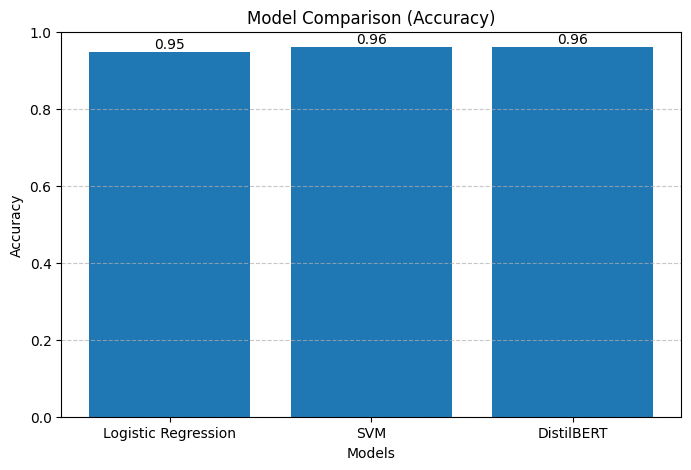

In [ ]:
model_names = ["Logistic Regression", "SVM", "DistilBERT"]
accuracies = [lr_accuracy, svm_accuracy, distilbert_accuracy]

compare_models(model_names, accuracies)

# Model Performance

In [ ]:
import pandas as pd
from sklearn.metrics import recall_score

# For DistilBERT, we use the 'results' dictionary from your trainer.evaluate() call
comparison_data = {
    "Model": ["Logistic Regression", "Linear SVM", "DistilBERT"],
    "Accuracy": [
        lr_accuracy,
        svm_acc,
        results['eval_accuracy']
    ],
    "Recall": [
        recall_score(y_test, lr_model.predict(X_test_tfidf)),
        recall_score(y_test, svm_model.predict(X_test_tfidf)),
        results['eval_recall']
    ]
}

# 2. Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# 3. Print the Table
print("\nFINAL MODEL PERFORMANCE COMPARISON")
print("=" * 45)
print(comparison_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))


FINAL MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Recall
Logistic Regression    0.9470  0.9498
         Linear SVM    0.9591  0.9574
         DistilBERT    0.9600  0.9091


# ROC CURVE COMPARE

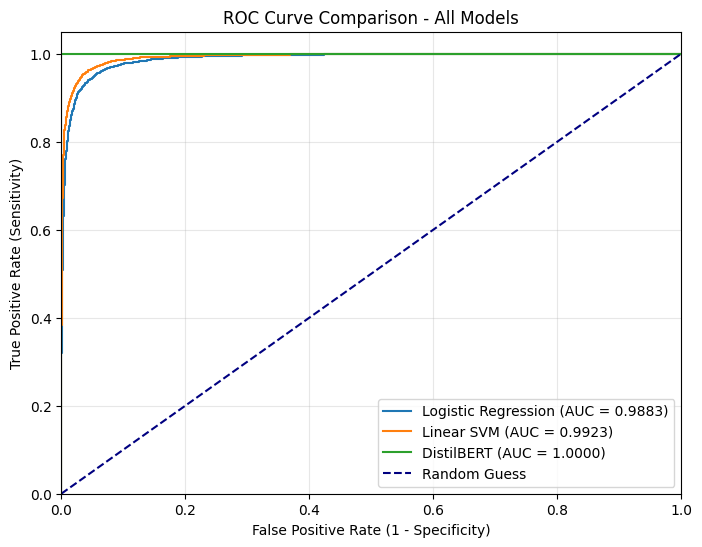

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Prepare Plot
plt.figure(figsize=(8, 6))

# --- LOGISTIC REGRESSION ---
# Using predict_proba to get probability for the positive class
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# --- LINEAR SVM ---
# LinearSVC uses decision_function instead of predict_proba
svm_scores = svm_model.decision_function(X_test_tfidf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC = {auc_svm:.4f})')

# --- DISTILBERT ---
# Getting predictions from the trainer for the test set
bert_outputs = trainer.predict(tokenized_datasets["test"])
# Apply softmax to get probabilities from logits
bert_probs = torch.nn.functional.softmax(torch.from_numpy(bert_outputs.predictions), dim=-1)[:, 1].numpy()
y_test_bert = bert_outputs.label_ids
fpr_bert, tpr_bert, _ = roc_curve(y_test_bert, bert_probs)
auc_bert = auc(fpr_bert, tpr_bert)
plt.plot(fpr_bert, tpr_bert, label=f'DistilBERT (AUC = {auc_bert:.4f})')

# 2. Finalize Plot Styling
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# learning Curve

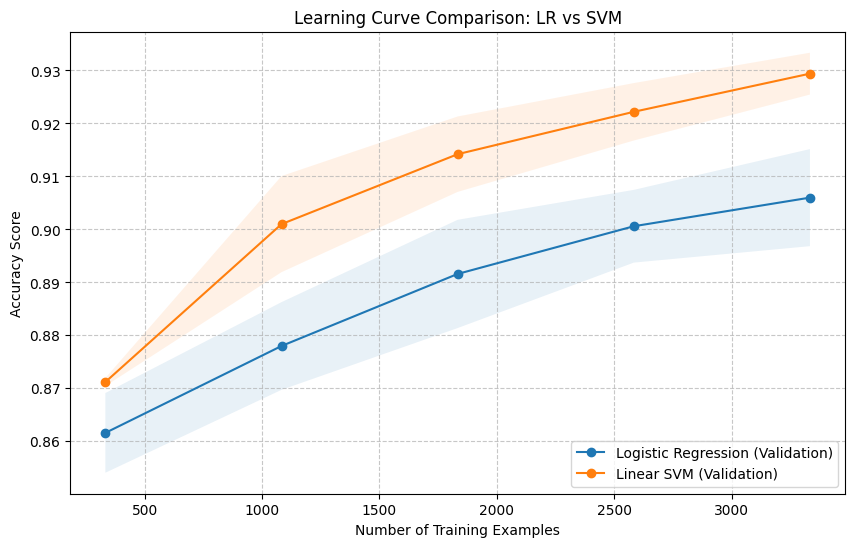

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def compare_ml_learning_curves(models, names, X, y):
    plt.figure(figsize=(10, 6))

    for model, name in zip(models, names):
        # Calculate learning curve data
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='accuracy'
        )

        # Calculate mean and standard deviation
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        # Plot the validation line for each model
        plt.plot(train_sizes, val_mean, 'o-', label=f"{name} (Validation)")
        plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

    plt.title("Learning Curve Comparison: LR vs SVM")
    plt.xlabel("Number of Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# EXECUTION: Compare your models using a 5,000 sample subset
compare_ml_learning_curves(
    [lr_model, svm_model],
    ["Logistic Regression", "Linear SVM"],
    X_train_tfidf[:5000],
    y_train[:5000]
)